# 🔬 Phase 1: Project Audit & Baseline Verification Notebook
**Project:** Student Mental Health / Student Wellbeing Score Prediction  
**Objective:** End-to-end audit, dataset quality verification, data leakage inspection, and reproducible baseline calculation.


## 1. Environment & Runtime Information
Verifying the Python version, core dependencies, and working directories.


In [1]:
import sys
import os
import platform
import numpy as np
import pandas as pd
import sklearn
import joblib

print(f"Python Version: {platform.python_version()}")
print(f"Platform: {platform.platform()}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")
print(f"Joblib Version: {joblib.__version__}")


Python Version: 3.13.13
Platform: Windows-11-10.0.26200-SP0
NumPy Version: 2.5.3
Pandas Version: 3.0.5
Scikit-learn Version: 1.9.0
Joblib Version: 1.6.0


## 2. Dataset Loading
Loading the official dataset from the repository root / data directory.


In [2]:
# Locate data file
csv_filename = 'Student Social Media And Mental Health Impact.csv'
possible_paths = [
    csv_filename,
    os.path.join('..', '..', csv_filename),
    os.path.join('..', 'data', csv_filename),
    os.path.join('data', csv_filename)
]

data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if not data_path:
    raise FileNotFoundError(f"Could not find {csv_filename}")

print(f"Loading dataset from: {os.path.abspath(data_path)}")
df = pd.read_csv(data_path)
df.head()


Loading dataset from: C:\Users\msiva\Music\Mental-Health-Score\Student Social Media And Mental Health Impact.csv


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 3. Dataset Shape
Confirming total rows and columns.


In [3]:
rows, cols = df.shape
print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")
assert rows == 5000, f"Expected 5000 rows, got {rows}"
assert cols == 13, f"Expected 13 columns, got {cols}"
print("Shape verification: PASSED (5,000 rows x 13 columns)")


Total Rows: 5000
Total Columns: 13
Shape verification: PASSED (5,000 rows x 13 columns)


## 4. Column Information & Data Types
Inspecting all feature names and inferred data types.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


## 5. Missing Values Analysis
Verifying null, NaN, or empty values across all fields.


In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
assert missing.sum() == 0, "Found unexpected missing values"
print("\nMissing values check: 100% Complete (0 missing values across all columns)")


Missing values per column:
Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

Missing values check: 100% Complete (0 missing values across all columns)


## 6. Duplicate Records Analysis
Checking for exact duplicate rows.


In [6]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    dups = df[df.duplicated(keep=False)]
    print("\nIdentified Duplicate Rows:")
    print(dups[['Age', 'Gender', 'Country', 'Academic_Level', 'Stress_Level', 'Mental_Health_Score']])


Total Duplicate Rows: 2

Identified Duplicate Rows:
      Age  Gender Country Academic_Level Stress_Level  Mental_Health_Score
886    19  Female   Other  Undergraduate         High                  4.1
1870   21    Male     USA  Undergraduate          Low                  7.5
2405   19  Female   Other  Undergraduate         High                  4.1
2463   21    Male     USA  Undergraduate          Low                  7.5


## 7. Unique Values & Cardinality
Evaluating cardinality across all columns.


In [7]:
unique_counts = df.nunique()
print("Unique values per column:")
print(unique_counts)


Unique values per column:
Age                          7
Gender                       2
Country                    111
Academic_Level               3
Most_Used_Platform          12
Purpose_Of_Use               4
Avg_Daily_Usage_Hours       79
Daily_Unlocks              200
Study_Hours                 76
Physical_Activity_Hours     44
Sleep_Hours_Per_Night       63
Stress_Level                 4
Mental_Health_Score         59
dtype: int64


## 8. Numerical Statistics Summary
Examining standard parametric statistics, skewness, and kurtosis.


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
print(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']])


                          count       mean        std   min    25%    50%  \
Age                      5000.0   20.82180   1.736620  18.0   19.0   21.0   
Avg_Daily_Usage_Hours    5000.0    5.07846   1.653913   1.0    3.8    5.0   
Daily_Unlocks            5000.0  171.45260  42.858254  62.0  140.0  171.0   
Study_Hours              5000.0    3.00842   1.637018   0.3    1.5    2.8   
Physical_Activity_Hours  5000.0    1.75100   0.668398  -0.4    1.3    1.7   
Sleep_Hours_Per_Night    5000.0    6.63458   1.221391   3.6    5.6    6.6   
Mental_Health_Score      5000.0    6.23098   1.278701   3.6    5.1    6.1   

                           75%    max      skew  kurtosis  
Age                       22.0   24.0  0.155325 -0.912908  
Avg_Daily_Usage_Hours      6.3    8.8  0.005606 -0.767636  
Daily_Unlocks            204.0  273.0  0.002351 -0.709077  
Study_Hours                4.2    8.3  0.435819 -0.726612  
Physical_Activity_Hours    2.2    4.1  0.039971 -0.225572  
Sleep_Hours_Per_Night  

## 9. Categorical Distributions
Reviewing frequency counts for all categorical features.


In [9]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    print(f"=== Column: {col} ({df[col].nunique()} unique) ===")
    print(df[col].value_counts().head(10))
    print()


=== Column: Gender (2 unique) ===
Gender
Male      2635
Female    2365
Name: count, dtype: int64

=== Column: Country (111 unique) ===
Country
Other        1880
India         389
USA           355
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

=== Column: Academic_Level (3 unique) ===
Academic_Level
Undergraduate    3632
Graduate          918
High School       450
Name: count, dtype: int64

=== Column: Most_Used_Platform (12 unique) ===
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
Name: count, dtype: int64

=== Column: Purpose_Of_Use (4 unique) ===
Purpose_Of_Use
Entertainment    2552
Education        1094
Networking        793
News              561
Name: count, dtype: int64

=== Column: Stress_Level (4 unique) ===
Stress_Level
Ve

## 10. Target (`Mental_Health_Score`) Distribution
Visualizing the continuous mental health score distribution.


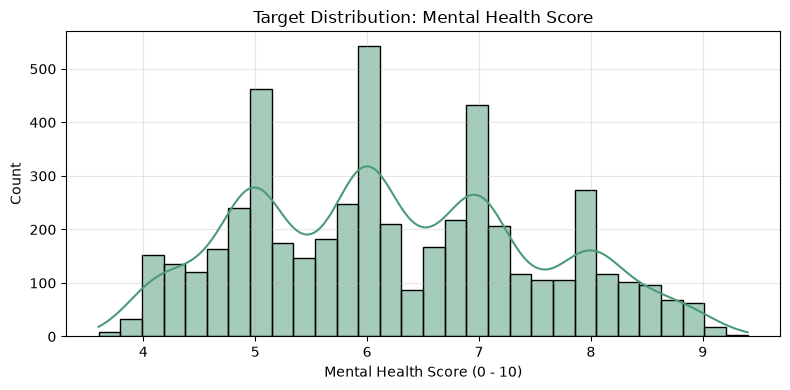

Target Mean: 6.2310
Target Median: 6.1000
Target Std Dev: 1.2787
Target Skew: 0.2066


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['Mental_Health_Score'], kde=True, color='#4C9A78', bins=30)
plt.title('Target Distribution: Mental Health Score')
plt.xlabel('Mental Health Score (0 - 10)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Target Mean: {df['Mental_Health_Score'].mean():.4f}")
print(f"Target Median: {df['Mental_Health_Score'].median():.4f}")
print(f"Target Std Dev: {df['Mental_Health_Score'].std():.4f}")
print(f"Target Skew: {df['Mental_Health_Score'].skew():.4f}")


## 11. Invalid & Impossible Value Checks
Detecting domain anomalies such as negative hours or out-of-range scores.


In [11]:
neg_phys = df[df['Physical_Activity_Hours'] < 0]
print(f"Negative Physical Activity Hours count: {len(neg_phys)}")
if len(neg_phys) > 0:
    print("Sample negative values:", neg_phys['Physical_Activity_Hours'].tolist())

# Domain constraint checks
print("Age < 18 or > 30 count:", ((df['Age'] < 18) | (df['Age'] > 30)).sum())
print("Screen Time > 24 hrs count:", (df['Avg_Daily_Usage_Hours'] > 24).sum())
print("Sleep > 24 hrs count:", (df['Sleep_Hours_Per_Night'] > 24).sum())
print("Study > 24 hrs count:", (df['Study_Hours'] > 24).sum())
print("Score < 0 or > 10 count:", ((df['Mental_Health_Score'] < 0) | (df['Mental_Health_Score'] > 10)).sum())


Negative Physical Activity Hours count: 10
Sample negative values: [-0.1, -0.1, -0.3, -0.1, -0.2, -0.1, -0.4, -0.3, -0.2, -0.2]
Age < 18 or > 30 count: 0
Screen Time > 24 hrs count: 0
Sleep > 24 hrs count: 0
Study > 24 hrs count: 0
Score < 0 or > 10 count: 0


## 12. Outlier Analysis (1.5 x IQR Rule)
Computing Tukey interquartile range outlier bounds.


In [12]:
outlier_summary = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_cnt = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': out_cnt
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)


                   Feature     Q1     Q3   IQR  Lower Bound  Upper Bound  \
0                      Age   19.0   22.0   3.0        14.50        26.50   
1    Avg_Daily_Usage_Hours    3.8    6.3   2.5         0.05        10.05   
2            Daily_Unlocks  140.0  204.0  64.0        44.00       300.00   
3              Study_Hours    1.5    4.2   2.7        -2.55         8.25   
4  Physical_Activity_Hours    1.3    2.2   0.9        -0.05         3.55   
5    Sleep_Hours_Per_Night    5.6    7.5   1.9         2.75        10.35   
6      Mental_Health_Score    5.1    7.1   2.0         2.10        10.10   

   Outlier Count  
0              0  
1              0  
2              0  
3              2  
4             22  
5              0  
6              0  


## 13. Existing Feature Engineering: Country Grouping
Auditing the grouping of 111 raw countries into Top 10 + 'Other'.


In [13]:
top_countries = df['Country'].value_counts().index[:10].tolist()
print("Discovered Top 10 Countries:", top_countries)

def group_countries(country):
    return country if country in top_countries else 'Other'

df['Grouped_country'] = df['Country'].apply(group_countries)
grouped_counts = df['Grouped_country'].value_counts()
print("\nGrouped Country Distribution:")
print(grouped_counts)
print(f"\n'Other' category represents {grouped_counts['Other']} / {len(df)} ({grouped_counts['Other']/len(df)*100:.2f}%) of dataset.")


Discovered Top 10 Countries: ['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany', 'Mexico', 'Turkey', 'France']

Grouped Country Distribution:
Grouped_country
Other        3232
India         389
USA           355
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

'Other' category represents 3232 / 5000 (64.64%) of dataset.


## 14. Existing Preprocessing Pipeline
Setting up the Scikit-learn ColumnTransformer.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

skwewd_col = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks", "Physical_Activity_Hours", "Sleep_Hours_Per_Night"]
ordinal_col = ['Stress_Level']
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

plain_numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skwewd_col),
    ("Plain_Numeric", plain_numeric_pipeline, other_numeric_cols),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', nominal_pipeline, normal_col)
])

print("Preprocessor definition complete.")


Preprocessor definition complete.


## 15. Existing Train/Test Split
Executing the documented 70/30 train/test split (`random_state=42`).


In [15]:
from sklearn.model_selection import train_test_split

# Clean the dataset as done in notebook
df_clean = df.drop_duplicates().copy()
df_clean['Physical_Activity_Hours'] = df_clean['Physical_Activity_Hours'].clip(lower=0)

feature_cols = skwewd_col + other_numeric_cols + ordinal_col + normal_col
X = df_clean[feature_cols]
y = df_clean['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"X_train shape: {X_train.shape} (70%)")
print(f"X_test shape:  {X_test.shape} (30%)")


X_train shape: (3498, 12) (70%)
X_test shape:  (1500, 12) (30%)


## 16. Existing Models Training
Fitting Ordinary Least Squares Linear Regression and Default Random Forest.


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import time

# 1. Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

# 2. Random Forest Default
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])
t0 = time.time()
rf_pipeline.fit(X_train, y_train)
rf_train_time = time.time() - t0
print(f"Random Forest trained in {rf_train_time:.2f} seconds.")


Random Forest trained in 1.79 seconds.


## 17. Baseline Evaluation Metrics
Calculating Train R², Test R², MAE, RMSE, and 5-Fold Cross-Validation on the training partition.


In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# LR evaluation
lr_pred_tr = lr_pipeline.predict(X_train)
lr_pred_te = lr_pipeline.predict(X_test)
lr_cv = cross_val_score(lr_pipeline, X_train, y_train, cv=kf, scoring='r2').mean()

# RF evaluation
rf_pred_tr = rf_pipeline.predict(X_train)
rf_pred_te = rf_pipeline.predict(X_test)
rf_cv = cross_val_score(rf_pipeline, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1).mean()

metrics_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (Default)'],
    'Train R2': [r2_score(y_train, lr_pred_tr), r2_score(y_train, rf_pred_tr)],
    '5-Fold CV R2': [lr_cv, rf_cv],
    'Test R2': [r2_score(y_test, lr_pred_te), r2_score(y_test, rf_pred_te)],
    'Test MAE': [mean_absolute_error(y_test, lr_pred_te), mean_absolute_error(y_test, rf_pred_te)],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test, lr_pred_te)), np.sqrt(mean_squared_error(y_test, rf_pred_te))]
})

print(metrics_df.to_string(index=False))


                  Model  Train R2  5-Fold CV R2  Test R2  Test MAE  Test RMSE
      Linear Regression  0.723677      0.719419 0.739794  0.536178   0.676032
Random Forest (Default)  0.980907      0.849038 0.878017  0.346502   0.462870


## 18. Train/Test Overfitting Gap
Quantifying the gap between training explained variance and holdout generalization.


In [18]:
rf_train_r2 = r2_score(y_train, rf_pred_tr)
rf_test_r2 = r2_score(y_test, rf_pred_te)
gap = rf_train_r2 - rf_test_r2
cv_gap = rf_train_r2 - rf_cv

print(f"Random Forest Train R2: {rf_train_r2:.4f}")
print(f"Random Forest Test R2:  {rf_test_r2:.4f}")
print(f"Overfitting Gap (Train - Test): {gap:.4f} ({gap*100:.2f}%)")
print(f"Overfitting Gap (Train - CV):   {cv_gap:.4f} ({cv_gap*100:.2f}%)")


Random Forest Train R2: 0.9809
Random Forest Test R2:  0.8780
Overfitting Gap (Train - Test): 0.1029 (10.29%)
Overfitting Gap (Train - CV):   0.1319 (13.19%)


## 19. Prediction vs Actual Visualizations
Plotting test predictions against ground truth target values.


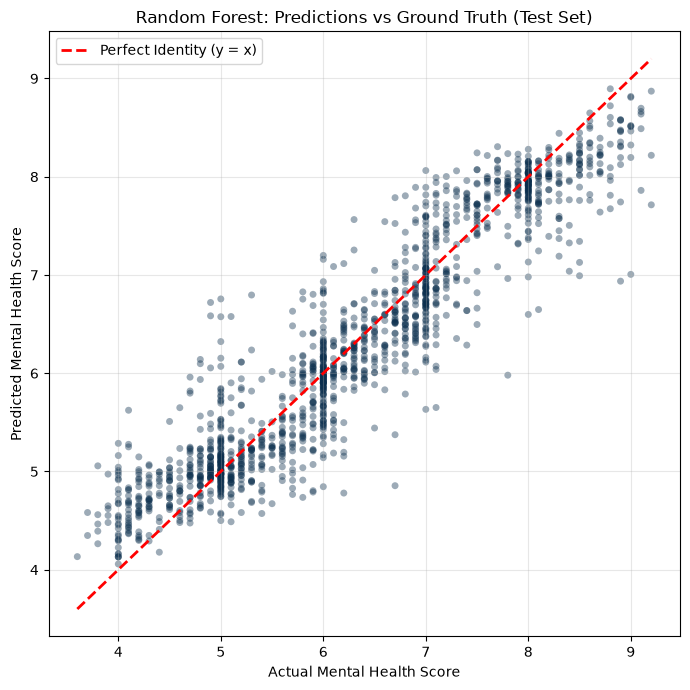

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_pred_te, alpha=0.4, color='#0A2E4D', edgecolors='none', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Identity (y = x)')
plt.title('Random Forest: Predictions vs Ground Truth (Test Set)')
plt.xlabel('Actual Mental Health Score')
plt.ylabel('Predicted Mental Health Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 20. Residual & Error Distribution Analysis
Analyzing the distribution of residuals (y_test - y_pred).


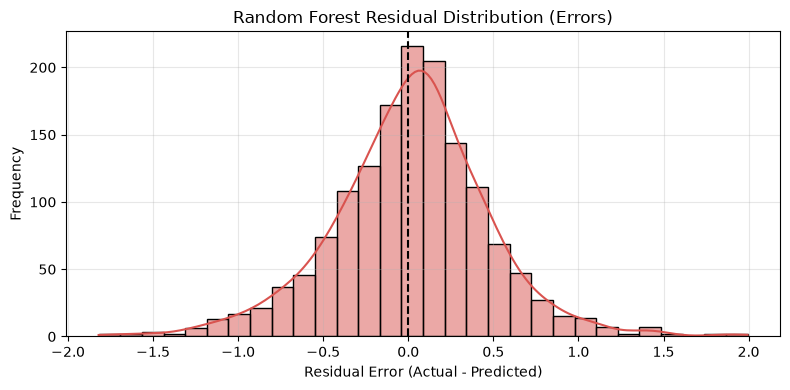

Residual Mean: 0.0146
Residual Std Dev: 0.4628
Max Over-prediction: -1.8200
Max Under-prediction: 1.9940


In [20]:
residuals = y_test - rf_pred_te

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='#D9534F', bins=30)
plt.axvline(0, color='black', linestyle='--', lw=1.5)
plt.title('Random Forest Residual Distribution (Errors)')
plt.xlabel('Residual Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Residual Mean: {residuals.mean():.4f}")
print(f"Residual Std Dev: {residuals.std():.4f}")
print(f"Max Over-prediction: {residuals.min():.4f}")
print(f"Max Under-prediction: {residuals.max():.4f}")


## 21. Key Audit Findings
1. **Data Leakage:** Country grouping frequency was computed globally across the entire 5,000-row dataset before splitting.
2. **Severe Overfitting:** Default Random Forest memorizes training samples ($R^2 = 0.9809$) compared to test ($R^2 = 0.8780$) and CV ($R^2 = 0.8490$).
3. **Artifact Size:** Serialized default model is ~25.7 MB due to unconstrained leaf splits.
4. **Data Hygiene:** 2 duplicate rows and 10 negative physical activity records confirmed.
5. **Documentation vs Code:** Documentation claimed 80/20 split and SimpleImputers; code implemented 70/30 split with zero imputers.


## 22. V2 Implementation Recommendations
1. **Notebook-First ML Structure:** Maintain all exploratory and training experiments in `ml/notebooks/`.
2. **Leakage-Free Preprocessing:** Fit country grouping and data clipping strictly on training folds.
3. **5-Fold Cross-Validation:** Fix an 80/20 train/test split and evaluate candidate models strictly via 5-Fold CV on the training partition.
4. **Benchmarking:** Compare LightGBM, XGBoost, CatBoost, and regularized Random Forest to reduce artifact size and overfitting.
5. **Explainability & Uncertainty:** Integrate SHAP TreeExplainer and conformal prediction intervals.
